## Energetic Consumption

In [1]:
import io
from pathlib import Path

import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from energy_sights.config import RAW_DATA_DIR, critical_features, target, INTERIM_DATA_DIR, PROCESSED_DATA_DIR
from energy_sights.features import engineer_features
from energy_sights.logging_config import setup_logging
from energy_sights.preprocessing import nan_percent, drop_constant_columns, clean_neighborhood, \
    find_case_insensitive_duplicates, numeric_describe, logarithm
from energy_sights.plots import plot_distribution, interactive_distribution, heat_correlation

2026-02-14 23:45:56.686 | INFO     | energy_sights.config:<module>:11 - PROJ_ROOT path is: C:\ML_projects\energy_sights


2026-02-14 23:45:56 | INFO     | energy_sights.preprocessing - Starting the Preprocessing
2026-02-14 23:45:56.721 | INFO     | energy_sights.preprocessing:<module>:12 - Starting the Preprocessing
2026-02-14 23:45:56 | SUCCESS  | energy_sights.preprocessing - End of the preprocessing
2026-02-14 23:45:56.727 | SUCCESS  | energy_sights.preprocessing:<module>:90 - End of the preprocessing


In [119]:
import importlib
import energy_sights.plots

In [123]:
importlib.reload(energy_sights.plots)
importlib.reload(energy_sights.features)

<module 'energy_sights.features' from 'C:\\ML_projects\\energy_sights\\energy_sights\\features.py'>

In [3]:
setup_logging()

In [4]:
# let's set all the parameters for the plots
sns.set_style(style='darkgrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['font.weight'] = 'bold'

# the axes object
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'

In [5]:
datafile_path = RAW_DATA_DIR / '2016_Building_Energy_Benchmarking.csv'

In [6]:
# noinspection PyArgumentList
df = pd.read_csv(filepath_or_buffer=datafile_path)

In [7]:
df.head(n=5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [8]:
df.shape

(3376, 46)

In [9]:
column_names = df.columns.tolist()

In [10]:
buffer = io.StringIO()
df.info(memory_usage='deep', verbose=True, buf=buffer)
df_information = buffer.getvalue()
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [11]:
column_names

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [12]:
# let's see the unique values in the zipcode column
df['ZipCode'].nunique()

55

In [13]:
df.nunique().rename('unique_values')

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [14]:
df['Neighborhood'].unique().tolist()

['DOWNTOWN',
 'SOUTHEAST',
 'NORTHEAST',
 'EAST',
 'Central',
 'NORTH',
 'MAGNOLIA / QUEEN ANNE',
 'LAKE UNION',
 'GREATER DUWAMISH',
 'BALLARD',
 'NORTHWEST',
 'CENTRAL',
 'SOUTHWEST',
 'DELRIDGE',
 'Ballard',
 'North',
 'Delridge',
 'Northwest',
 'DELRIDGE NEIGHBORHOODS']

## **Data Cleansing**

In [15]:
# deletion of the constant columns
constant_columns = df.nunique()[df.nunique().apply(func=lambda x: x == 1)].index.tolist()

In [16]:
df.nunique().apply(func=lambda x: x == 1).rename('unique_values')

OSEBuildingID                      False
DataYear                            True
BuildingType                       False
PrimaryPropertyType                False
PropertyName                       False
Address                            False
City                                True
State                               True
ZipCode                            False
TaxParcelIdentificationNumber      False
CouncilDistrictCode                False
Neighborhood                       False
Latitude                           False
Longitude                          False
YearBuilt                          False
NumberofBuildings                  False
NumberofFloors                     False
PropertyGFATotal                   False
PropertyGFAParking                 False
PropertyGFABuilding(s)             False
ListOfAllPropertyUseTypes          False
LargestPropertyUseType             False
LargestPropertyUseTypeGFA          False
SecondLargestPropertyUseType       False
SecondLargestPro

In [17]:
constant_columns

['DataYear', 'City', 'State']

In [18]:
df.nunique()

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


In [19]:
df['ComplianceStatus'].unique().tolist()

['Compliant', 'Error - Correct Default Data', 'Missing Data', 'Non-Compliant']

In [20]:
df['ComplianceStatus'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [21]:
df = drop_constant_columns(df=df)

2026-02-14 23:46:14 | INFO     | energy_sights.preprocessing - The constant columns of the dataframe are: ['DataYear', 'City', 'State']
2026-02-14 23:46:14.702 | INFO     | energy_sights.preprocessing:drop_constant_columns:16 - The constant columns of the dataframe are: ['DataYear', 'City', 'State']


In [22]:
df['DefaultData'].unique().tolist()

[False, True]

In [23]:
df['DefaultData'].value_counts(normalize=True, sort=True, ascending=False, dropna=True
                               )

DefaultData
False    0.966528
True     0.033472
Name: proportion, dtype: float64

In [24]:
# let's explore the PrimaryPropertyUseType
df['PrimaryPropertyType'].unique().tolist()

['Hotel',
 'Other',
 'Mid-Rise Multifamily',
 'Mixed Use Property',
 'K-12 School',
 'University',
 'Small- and Mid-Sized Office',
 'Self-Storage Facility',
 'Warehouse',
 'Large Office',
 'Senior Care Community',
 'Medical Office',
 'Retail Store',
 'Hospital',
 'Residence Hall',
 'Distribution Center',
 'Worship Facility',
 'Low-Rise Multifamily',
 'Supermarket / Grocery Store',
 'Laboratory',
 'Refrigerated Warehouse',
 'Restaurant',
 'High-Rise Multifamily',
 'Office']

In [25]:
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [26]:
df.filter(items=['PrimaryPropertyType'])

,PrimaryPropertyType
0,Hotel
1,Hotel
2,Hotel
3,Hotel
4,Hotel
...,...
3371,Office
3372,Other
3373,Other
3374,Mixed Use Property


In [27]:
# let's explore the LargestPropertyUseType column
df['LargestPropertyUseType'].value_counts(normalize=False, ascending=False, sort=True, dropna=False)

LargestPropertyUseType
Multifamily Housing                                     1667
Office                                                   498
Non-Refrigerated Warehouse                               199
K-12 School                                              139
Other                                                    102
Retail Store                                              99
Hotel                                                     77
Worship Facility                                          71
Distribution Center                                       54
Senior Care Community                                     46
Medical Office                                            41
Supermarket/Grocery Store                                 41
Parking                                                   32
Other - Recreation                                        31
Self-Storage Facility                                     28
College/University                                        25
R

In [28]:
# let's now see the unique values of this variable
df['LargestPropertyUseType'].nunique()

56

In [29]:
df['BuildingType'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

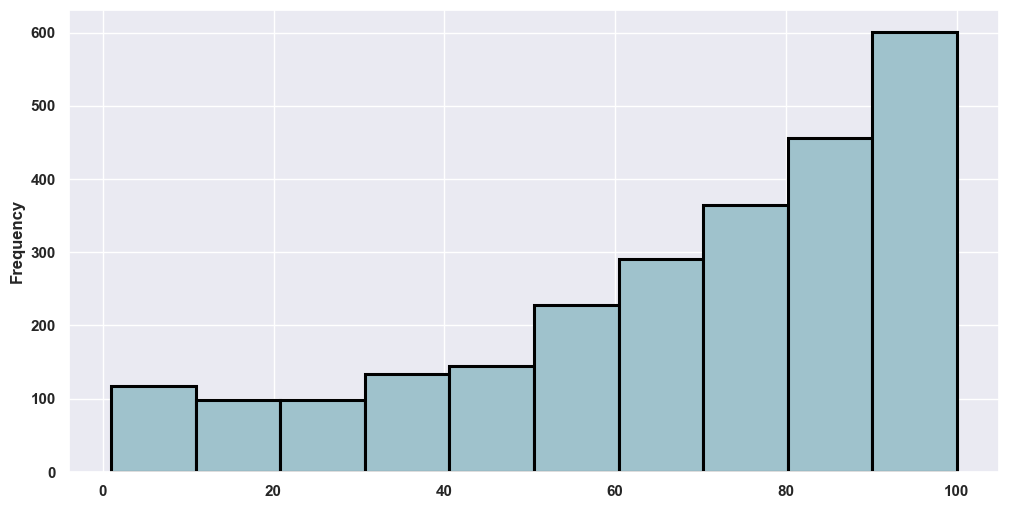

In [30]:
df['ENERGYSTARScore'].plot(kind='hist', ec='k', color='#9FC2CC', lw=2.2)

In [31]:
print(df_information)

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [32]:
# let's explore the number of building column
df['NumberofBuildings'].value_counts(normalize=False, dropna=False, sort=True, ascending=True)

NumberofBuildings
27.0        1
11.0        1
7.0         1
16.0        1
23.0        1
111.0       1
14.0        2
9.0         2
10.0        2
8.0         3
6.0         5
NaN         8
5.0        10
4.0        12
3.0        22
2.0        37
0.0        92
1.0      3175
Name: count, dtype: int64

In [33]:
df['NumberofBuildings'].nunique()
df['NumberofFloors'].nunique()

50

In [34]:
# let's filter the data to keep only the compliant compliant_status and the False Default
df['ComplianceStatus'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

ComplianceStatus
Compliant                       3211
Error - Correct Default Data     113
Non-Compliant                     37
Missing Data                      15
Name: count, dtype: int64

In [35]:
df['DefaultData'].value_counts(normalize=False, sort=True, ascending=False, dropna=False)

DefaultData
False    3263
True      113
Name: count, dtype: int64

In [36]:
# Filter of the compliant status in the compliance status column and the defaultdata column
df_compliant = df.query(expr="(ComplianceStatus == 'Compliant') and (DefaultData == False)", inplace=False)

In [37]:
df_compliant.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 3211 entries, 0 to 3375
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3211 non-null   int64  
 1   BuildingType                     3211 non-null   str    
 2   PrimaryPropertyType              3211 non-null   str    
 3   PropertyName                     3211 non-null   str    
 4   Address                          3211 non-null   str    
 5   ZipCode                          3198 non-null   float64
 6   TaxParcelIdentificationNumber    3211 non-null   str    
 7   CouncilDistrictCode              3211 non-null   int64  
 8   Neighborhood                     3211 non-null   str    
 9   Latitude                         3211 non-null   float64
 10  Longitude                        3211 non-null   float64
 11  YearBuilt                        3211 non-null   int64  
 12  NumberofBuildings                320

In [38]:
df_compliant.shape

(3211, 43)

## PropertyGFAParking

In [39]:
# let's check the data in the column PropertyParkingGFA
df_compliant['PropertyGFAParking'].head()

0         0
1     15064
2    196718
3         0
4     62000
Name: PropertyGFAParking, dtype: int64

In [40]:
numeric_describe(df=df_compliant, col='PropertyGFAParking').to_dict()

{'count': 3211.0,
 'mean': 8363.015882902522,
 'std': 33090.18405035005,
 'min': 0.0,
 '25%': 0.0,
 '50%': 0.0,
 '75%': 0.0,
 'max': 512608.0,
 'mode': 0.0}

In [41]:
interactive_distribution(df=df_compliant, col='PropertyGFAParking')

### Because of all the information we get from this feature, we'll use it finally for the training of the model

## I think we'll continue all the work with the compliant buildings to ensure the quality of the prediction

In [42]:
column_names

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [43]:
critical_features

['PrimaryPropertyType',
 'YearBuilt',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'BuildingType',
 'Latitude',
 'Longitude']

In [44]:
# let's select all the column and the specific target for the siteEnergyUse prediction
df_compliant_filtered = df_compliant.filter(items=critical_features + target)

In [45]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
0,Hotel,1927,88434,0,DOWNTOWN,1.0,12,NonResidential,47.61220,-122.33799,7226362.5,249.98
1,Hotel,1996,103566,15064,DOWNTOWN,1.0,11,NonResidential,47.61317,-122.33393,8387933.0,295.86
2,Hotel,1969,956110,196718,DOWNTOWN,1.0,41,NonResidential,47.61393,-122.33810,72587024.0,2089.28
3,Hotel,1926,61320,0,DOWNTOWN,1.0,10,NonResidential,47.61412,-122.33664,6794584.0,286.43
4,Hotel,1980,175580,62000,DOWNTOWN,1.0,18,NonResidential,47.61375,-122.34047,14172606.0,505.01


In [46]:
# the primarypropertytype
df_compliant_filtered.nunique()

PrimaryPropertyType      23
YearBuilt               113
PropertyGFATotal       3041
PropertyGFAParking      485
Neighborhood             19
NumberofBuildings        17
NumberofFloors           50
BuildingType              8
Latitude               2744
Longitude              2536
SiteEnergyUse(kBtu)    3211
TotalGHGEmissions      2700
dtype: int64

In [47]:
# let's also have the information of the filtered dataframe
buffer = io.StringIO()
df_compliant_filtered.info(memory_usage='deep', buf=buffer)
final_information = buffer.getvalue()
print(final_information)

<class 'pandas.DataFrame'>
Index: 3211 entries, 0 to 3375
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PrimaryPropertyType  3211 non-null   str    
 1   YearBuilt            3211 non-null   int64  
 2   PropertyGFATotal     3211 non-null   int64  
 3   PropertyGFAParking   3211 non-null   int64  
 4   Neighborhood         3211 non-null   str    
 5   NumberofBuildings    3208 non-null   float64
 6   NumberofFloors       3211 non-null   int64  
 7   BuildingType         3211 non-null   str    
 8   Latitude             3211 non-null   float64
 9   Longitude            3211 non-null   float64
 10  SiteEnergyUse(kBtu)  3211 non-null   float64
 11  TotalGHGEmissions    3207 non-null   float64
dtypes: float64(5), int64(4), str(3)
memory usage: 851.9 KB



In [48]:
nan_percent(df=df_compliant_filtered)

PrimaryPropertyType ->  0.0000 %

YearBuilt ->  0.0000 %

PropertyGFATotal ->  0.0000 %

PropertyGFAParking ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofBuildings ->  0.0009 %

NumberofFloors ->  0.0000 %

BuildingType ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0012 %



In [49]:
df_compliant_filtered[df_compliant_filtered['TotalGHGEmissions'].isna()].filter(items=['NumberofBuildings', 'TotalGHGEmissions'])

,NumberofBuildings,TotalGHGEmissions
1768,NaN,NaN
2321,NaN,NaN
2480,NaN,NaN
3348,1.0,NaN


In [50]:
df_compliant_filtered[df_compliant_filtered['TotalGHGEmissions'].isnull()]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
1768,Low-Rise Multifamily,1992,29357,0,SOUTHWEST,NaN,4,Multifamily LR (1-4),47.54731,-122.38656,5.636832e+05,NaN
2321,Low-Rise Multifamily,1963,28472,0,NORTHEAST,NaN,4,Multifamily LR (1-4),47.67025,-122.31232,7.702755e+05,NaN
2480,Low-Rise Multifamily,1969,30420,0,SOUTHWEST,NaN,3,Multifamily LR (1-4),47.58968,-122.38587,1.049639e+06,NaN
3348,Low-Rise Multifamily,2015,36685,8254,EAST,1.0,4,Multifamily LR (1-4),47.62441,-122.31300,8.202201e+05,NaN


In [51]:
# let's check hte name of the buildings with the nan values on the column TotalGHGEmissions
df_compliant[df_compliant['TotalGHGEmissions'].isna()]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
1768,23355,Multifamily LR (1-4),Low-Rise Multifamily,GRAHAM VIEW,6040 CALIFORNIA AVE SW,98136.0,7625703280,1,SOUTHWEST,47.54731,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN
2321,25431,Multifamily LR (1-4),Low-Rise Multifamily,PONDERAY APTS,5625 15TH AVE NE,98105.0,5226300030,4,NORTHEAST,47.67025,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN
2480,25763,Multifamily LR (1-4),Low-Rise Multifamily,Villa Andora,1520 CALIFORNIA AVE SW,98116.0,9272201340,1,SOUTHWEST,47.58968,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN
3348,50082,Multifamily LR (1-4),Low-Rise Multifamily,STREAM FIFTEEN,605 15TH AVE E,98112.0,3303700030,3,EAST,47.62441,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,NaN,NaN,NaN


In [52]:
# let's see the nan values in the column NumberofBuildings
df_compliant_filtered[df_compliant_filtered['NumberofBuildings'].isna()]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
1768,Low-Rise Multifamily,1992,29357,0,SOUTHWEST,NaN,4,Multifamily LR (1-4),47.54731,-122.38656,5.636832e+05,NaN
2321,Low-Rise Multifamily,1963,28472,0,NORTHEAST,NaN,4,Multifamily LR (1-4),47.67025,-122.31232,7.702755e+05,NaN
2480,Low-Rise Multifamily,1969,30420,0,SOUTHWEST,NaN,3,Multifamily LR (1-4),47.58968,-122.38587,1.049639e+06,NaN


In [53]:
# to avoid imputation let's remove this lines
# because of the disposition of all the nans in this column and NumberofBuildings, let's remove all the nans in the column
# TotalGHGEmissions
df_compliant_filtered = df_compliant_filtered.dropna(axis=0, subset='TotalGHGEmissions', inplace=False, ignore_index=False, how='any')

In [54]:
# let's verify the stuff
nan_percent(df=df_compliant_filtered)

PrimaryPropertyType ->  0.0000 %

YearBuilt ->  0.0000 %

PropertyGFATotal ->  0.0000 %

PropertyGFAParking ->  0.0000 %

Neighborhood ->  0.0000 %

NumberofBuildings ->  0.0000 %

NumberofFloors ->  0.0000 %

BuildingType ->  0.0000 %

Latitude ->  0.0000 %

Longitude ->  0.0000 %

SiteEnergyUse(kBtu) ->  0.0000 %

TotalGHGEmissions ->  0.0000 %



In [55]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
0,Hotel,1927,88434,0,DOWNTOWN,1.0,12,NonResidential,47.61220,-122.33799,7226362.5,249.98
1,Hotel,1996,103566,15064,DOWNTOWN,1.0,11,NonResidential,47.61317,-122.33393,8387933.0,295.86
2,Hotel,1969,956110,196718,DOWNTOWN,1.0,41,NonResidential,47.61393,-122.33810,72587024.0,2089.28
3,Hotel,1926,61320,0,DOWNTOWN,1.0,10,NonResidential,47.61412,-122.33664,6794584.0,286.43
4,Hotel,1980,175580,62000,DOWNTOWN,1.0,18,NonResidential,47.61375,-122.34047,14172606.0,505.01


In [56]:
df_compliant_filtered.describe(include='all')

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
count,3207,3207.000000,3.207000e+03,3207.000000,3207,3207.000000,3207.000000,3207,3207.000000,3207.000000,3.207000e+03,3207.000000
unique,23,NaN,NaN,NaN,19,NaN,NaN,8,NaN,NaN,NaN,NaN
top,Low-Rise Multifamily,NaN,NaN,NaN,DOWNTOWN,NaN,NaN,NonResidential,NaN,NaN,NaN,NaN
freq,952,NaN,NaN,NaN,556,NaN,NaN,1432,NaN,NaN,NaN,NaN
mean,NaN,1968.719676,9.587476e+04,8370.873090,NaN,1.111007,4.806049,NaN,47.624565,-122.335118,5.539669e+06,122.211886
std,NaN,33.171462,2.229174e+05,33109.830984,NaN,2.159319,5.594795,NaN,0.047003,0.026554,2.212364e+07,551.534876
min,NaN,1900.000000,1.128500e+04,0.000000,NaN,0.000000,0.000000,NaN,47.502240,-122.414250,5.713320e+04,-0.800000
25%,NaN,1948.000000,2.829350e+04,0.000000,NaN,1.000000,2.000000,NaN,47.601055,-122.350350,9.387549e+05,9.640000
50%,NaN,1975.000000,4.387800e+04,0.000000,NaN,1.000000,4.000000,NaN,47.618910,-122.332630,1.809587e+06,33.920000
75%,NaN,1997.000000,9.158000e+04,0.000000,NaN,1.000000,5.000000,NaN,47.656745,-122.320215,4.277747e+06,94.385000


In [57]:
# let's put this data in the /data/interim !
df_compliant_filtered.to_csv(path_or_buf=INTERIM_DATA_DIR / 'df_compliant_filtered.csv', index=False)

## Comparison of the columns PrimaryPropertyType and BuildingType

In [58]:
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, ascending=False, sort=True, dropna=False)

PrimaryPropertyType
Low-Rise Multifamily           952
Mid-Rise Multifamily           553
Small- and Mid-Sized Office    287
Other                          250
Warehouse                      185
Large Office                   169
Mixed Use Property             132
High-Rise Multifamily          103
Retail Store                    85
Hotel                           76
Worship Facility                69
Distribution Center             53
K-12 School                     50
Senior Care Community           44
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      25
Residence Hall                  23
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Name: count, dtype: int64

In [59]:
df_compliant_filtered['BuildingType'].value_counts(normalize=False, sort=True, ascending=True, dropna=True)

BuildingType
Nonresidential WA          1
SPS-District K-12         10
Campus                    24
Nonresidential COS        81
Multifamily HR (10+)     108
Multifamily MR (5-9)     570
Multifamily LR (1-4)     981
NonResidential          1432
Name: count, dtype: int64

In [60]:
building_type: list[str] = sorted(df_compliant_filtered['BuildingType'].unique().tolist(), reverse=False)

In [61]:
building_type

['Campus',
 'Multifamily HR (10+)',
 'Multifamily LR (1-4)',
 'Multifamily MR (5-9)',
 'NonResidential',
 'Nonresidential COS',
 'Nonresidential WA',
 'SPS-District K-12']

In [62]:
residential_buildings = building_type[1:4]

In [63]:
residential_buildings

['Multifamily HR (10+)', 'Multifamily LR (1-4)', 'Multifamily MR (5-9)']

In [64]:
# let's filter the column to the nonresidential values
df_compliant_filtered = df_compliant_filtered.query(expr="BuildingType not in @residential_buildings")

In [65]:
# let's check the shape of the data in the dataframe
df_compliant_filtered.shape

(1548, 12)

In [66]:
# let's check the unique categories in this variable
df_compliant_filtered['BuildingType'].unique().tolist()

['NonResidential',
 'Nonresidential COS',
 'Campus',
 'SPS-District K-12',
 'Nonresidential WA']

In [67]:
# let's see with a pd.crosstab the values
pd.crosstab(columns=df_compliant_filtered['BuildingType'], index=df_compliant_filtered['PrimaryPropertyType'], dropna=True, values=None,
            margins=True, margins_name='Total')

BuildingType,Campus,NonResidential,Nonresidential COS,Nonresidential WA,SPS-District K-12,Total
PrimaryPropertyType,,,,,,
Distribution Center,0,51,2,0,0,53
Hospital,0,10,0,0,0,10
Hotel,0,75,0,0,0,75
K-12 School,4,38,0,0,8,50
Laboratory,0,10,0,0,0,10
Large Office,1,164,4,0,0,169
Low-Rise Multifamily,1,1,0,0,0,2
Medical Office,0,38,1,0,0,39
Mixed Use Property,4,101,8,0,0,113


In [68]:
# let's check the category NonResidential WA
df_compliant_filtered[df_compliant_filtered['BuildingType'] == 'Nonresidential WA']

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,BuildingType,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
3359,University,1962,68072,0,NORTHEAST,1.0,1,Nonresidential WA,47.66127,-122.31256,3180819.25,22.17


In [69]:
# let's check the name of this building
df_compliant[df_compliant['BuildingType'] == 'Nonresidential WA']

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3359,50101,Nonresidential WA,University,Burke Museum,4331 Memorial Way NE,98195.0,1625049001,4,NORTHEAST,47.66127,...,932244.6875,3180819.0,0.0,0.0,False,NaN,Compliant,NaN,22.17,0.33


In [70]:
df_compliant_filtered['BuildingType'].value_counts(normalize=True, sort=True, ascending=False)

BuildingType
NonResidential        0.925065
Nonresidential COS    0.052326
Campus                0.015504
SPS-District K-12     0.006460
Nonresidential WA     0.000646
Name: proportion, dtype: float64

### Because of the weak variance in this column, I'll remove it because it will introduce bias in the model
### Also, this column don't add meaningful information, because already know we are studying non-residential buildings

In [71]:
# let's drop this column
df_compliant_filtered = df_compliant_filtered.drop(columns='BuildingType')

In [72]:
# let's see the Primary property type column also
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, sort=True, ascending=False)

PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             2
Name: count, dtype: int64

### Our predictions are focus on the non-residential buildings but Low_Rise Multifamily is a Residential one
### so let's drop this category

In [73]:
df_compliant_filtered = df_compliant_filtered.loc[(df_compliant_filtered['PrimaryPropertyType'] != "Low-Rise Multifamily"), :]

In [74]:
df_compliant_filtered['PrimaryPropertyType'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Name: count, dtype: int64

### Replacement of the small categories with the biggest and higher semantically and related fields

#### We will put the category Restaurant in the category Retail Store because those activities is quietly similar

In [75]:
# here I will map all the categories with less than 15 values by a semantic related category to avoid the possible
# overfitting
df_compliant_filtered['PrimaryPropertyType'] = df_compliant_filtered['PrimaryPropertyType'].replace(to_replace={
    'Refrigerated Warehouse': 'Warehouse',
    'Hospital': 'Medical Office',
    'Laboratory': 'Medical Office',
    'Restaurant': 'Retail Store'
})

## Neighborhood

In [76]:
df_compliant_filtered['Neighborhood'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

Neighborhood
DOWNTOWN                  350
GREATER DUWAMISH          328
MAGNOLIA / QUEEN ANNE     144
LAKE UNION                142
NORTHEAST                 117
EAST                      116
NORTHWEST                  74
BALLARD                    58
NORTH                      51
CENTRAL                    42
DELRIDGE                   36
SOUTHWEST                  31
SOUTHEAST                  31
North                       8
Ballard                     5
Delridge                    4
Northwest                   4
Central                     4
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

In [77]:
df_compliant_filtered['Neighborhood'].unique().tolist()

['DOWNTOWN',
 'NORTHEAST',
 'EAST',
 'LAKE UNION',
 'GREATER DUWAMISH',
 'MAGNOLIA / QUEEN ANNE',
 'BALLARD',
 'NORTHWEST',
 'CENTRAL',
 'SOUTHWEST',
 'SOUTHEAST',
 'DELRIDGE',
 'NORTH',
 'North',
 'Delridge',
 'Ballard',
 'Northwest',
 'Central',
 'DELRIDGE NEIGHBORHOODS']

In [78]:
count: dict[str, int] = {}
for val in df_compliant_filtered['Neighborhood'].unique().tolist():
    if val.lower() not in count.keys():
        count[val.lower()] = 1
    else:
        count[val.lower()] += 1

duplicated_values: dict[str, int] = {k:v for k, v in count.items() if v > 1}

In [79]:
find_case_insensitive_duplicates(df=df_compliant_filtered, col='Neighborhood')

2026-02-14 23:46:43 | INFO     | energy_sights.preprocessing - Found 5 case-insensitive duplicates in 'Neighborhood'.
2026-02-14 23:46:43.649 | INFO     | energy_sights.preprocessing:find_case_insensitive_duplicates:59 - Found 5 case-insensitive duplicates in 'Neighborhood'.


{'ballard': 2, 'central': 2, 'delridge': 2, 'north': 2, 'northwest': 2}

In [80]:
# now let's clean the column Neighborhood
df_compliant_filtered = clean_neighborhood(df=df_compliant_filtered)

In [81]:
df_compliant_filtered['Neighborhood'].unique().tolist()

['Downtown',
 'Northeast',
 'East',
 'Lake Union',
 'Greater Duwamish',
 'Magnolia / Queen Anne',
 'Ballard',
 'Northwest',
 'Central',
 'Southwest',
 'Southeast',
 'Delridge Neighborhoods',
 'North']

In [82]:
# let's verify the quality of the cleaning
find_case_insensitive_duplicates(df=df_compliant_filtered, col='Neighborhood')

{}

In [83]:
df_compliant_filtered.Neighborhood.nunique()

13

In [148]:
df_compliant_filtered['Neighborhood'].value_counts(normalize=False, sort=True, ascending=False
                                                   )

Neighborhood
Downtown                  336
Greater Duwamish          320
Magnolia / Queen Anne     140
Lake Union                137
Northeast                 116
East                      107
Northwest                  75
Ballard                    63
North                      56
Central                    44
Delridge Neighborhoods     38
Southeast                  30
Southwest                  29
Name: count, dtype: int64

## YearBuilt column

In [84]:
df_compliant_filtered['YearBuilt'].unique().tolist()

[1927,
 1996,
 1969,
 1926,
 1980,
 1999,
 1904,
 1998,
 1928,
 1922,
 2004,
 1930,
 1983,
 1907,
 1916,
 1985,
 2001,
 1991,
 1978,
 1906,
 1994,
 1955,
 1992,
 1961,
 1990,
 1900,
 1954,
 1911,
 1973,
 1920,
 1910,
 1982,
 1908,
 1959,
 2000,
 1997,
 1962,
 1970,
 2008,
 1965,
 1929,
 2010,
 1938,
 1986,
 2002,
 1923,
 2003,
 1941,
 2006,
 1915,
 1950,
 1958,
 2009,
 2011,
 1971,
 2007,
 1951,
 1964,
 1953,
 1937,
 1966,
 1957,
 1968,
 1924,
 2005,
 1931,
 1972,
 1952,
 1914,
 1913,
 1995,
 1981,
 1989,
 1925,
 1976,
 1909,
 1988,
 1979,
 1947,
 1984,
 1956,
 1912,
 1977,
 1960,
 1945,
 1963,
 1974,
 1975,
 1946,
 1967,
 1987,
 1949,
 1940,
 1932,
 1948,
 1993,
 1918,
 1905,
 1902,
 1921,
 1939,
 1944,
 1917,
 1942,
 1903,
 2012,
 2013,
 1919,
 1901,
 1936,
 1935,
 2014,
 2015]

In [85]:
df_compliant_filtered.YearBuilt.nunique()

113

In [86]:
df_compliant_filtered['YearBuilt'].mode().rename(index={0: 'mode1', 1: 'mode2'})

mode1    1900
Name: YearBuilt, dtype: int64

In [87]:
df_compliant_filtered['YearBuilt'].value_counts(normalize=False, dropna=True, ascending=False, sort=True)

YearBuilt
1900    43
1970    31
2000    29
1910    28
1979    28
        ..
1942     2
1901     2
1903     1
1936     1
1935     1
Name: count, Length: 113, dtype: int64

In [88]:
numeric_describe(df=df_compliant_filtered, col='YearBuilt')

count    1546.000000
mean     1961.631953
std        32.889927
min      1900.000000
25%      1930.000000
50%      1965.500000
75%      1989.000000
max      2015.000000
mode     1900.000000
Name: YearBuilt, dtype: float64

In [89]:
# let's analyze the data based on the YearBuilt of the buildings
df[df['YearBuilt'] >= 2000][['PropertyName', 'PropertyGFATotal', 'NumberofFloors', 'NumberofBuildings', 'YearBuilt']]

,PropertyName,PropertyGFATotal,NumberofFloors,NumberofBuildings,YearBuilt
15,The Seattle Public Library - Central Library,412000,11,1.0,2004
23,WATERTOWN HOTEL,88592,6,1.0,2001
27,Marriott Springhill Suites (33),171866,10,1.0,2001
53,Rainier Hospitality,150453,7,1.0,2000
61,SCCA - ALLIANCE HOUSE,84103,6,1.0,2008
...,...,...,...,...,...
3358,1806,20246,4,1.0,2014
3360,Northgate Community Center,20616,1,1.0,2005
3361,Fire Station 06 (New),11685,1,1.0,2013
3362,Fire Station 35 (New),11968,1,1.0,2010


In [90]:
df[df['YearBuilt'] == df['YearBuilt'].max()][['PropertyGFATotal', 'PropertyName', 'NumberofBuildings', 'NumberofFloors', 'YearBuilt', 'SiteEnergyUse(kBtu)']]\
    .sort_values(by='SiteEnergyUse(kBtu)', ascending=False, kind='quicksort')

,PropertyGFATotal,PropertyName,NumberofBuildings,NumberofFloors,YearBuilt,SiteEnergyUse(kBtu)
3356,345290,AIBS,1.0,6,2015,3.936412e+07
3317,513816,Dexter Station,1.0,10,2015,1.876077e+07
3354,325000,Terry Hall & Maple Hall,1.0,7,2015,1.646749e+07
3333,319481,Cirrus,1.0,40,2015,1.540416e+07
3324,483397,"Sidneysea, LLC",1.0,12,2015,1.399864e+07
3323,271922,Junction 47,2.0,6,2015,7.682562e+06
3316,283479,Angeline Apartments,1.0,6,2015,6.821833e+06
3349,213952,Rooster Apartments,1.0,7,2015,6.562458e+06
3319,144614,Hilton Garden Inn Seattle,1.0,14,2015,5.525072e+06
3344,260051,Astro Apartments,1.0,7,2015,5.328224e+06


2026-02-14 23:46:48 | INFO     | energy_sights.plots - Plotting distribution for column: YearBuilt
2026-02-14 23:46:48.939 | INFO     | energy_sights.plots:plot_distribution:26 - Plotting distribution for column: YearBuilt


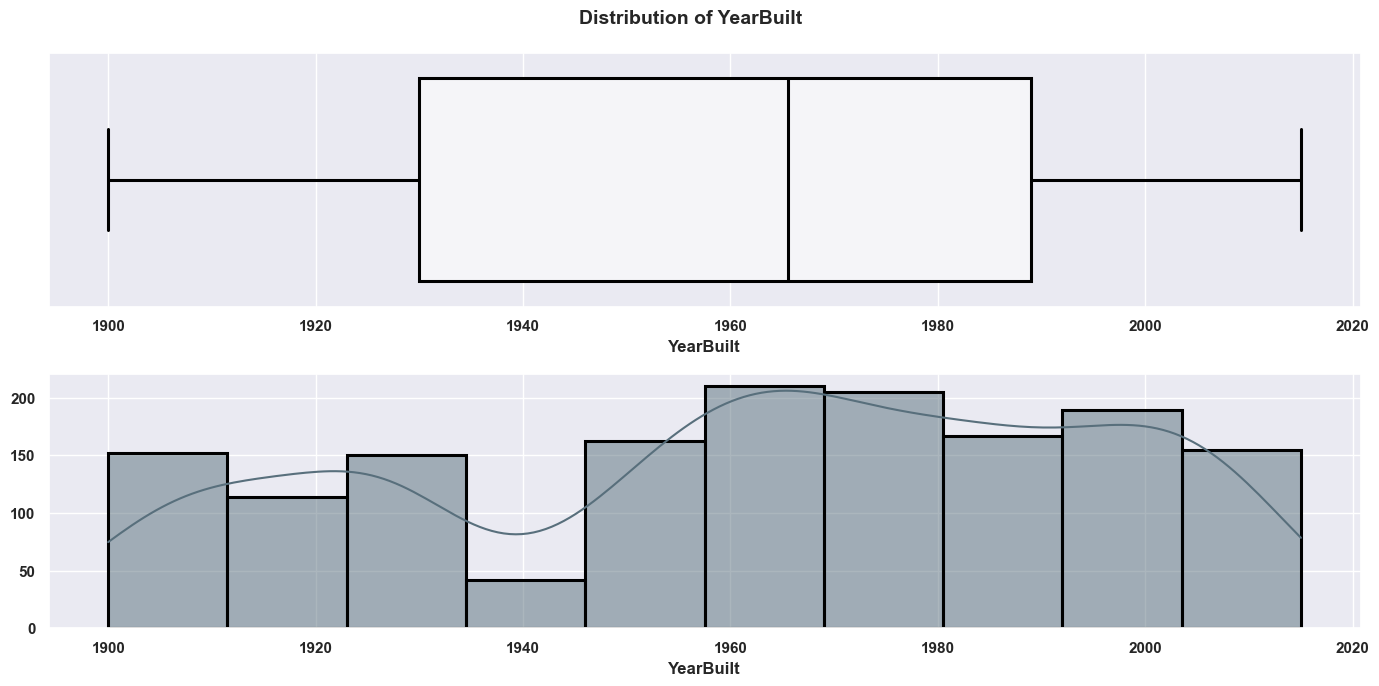

2026-02-14 23:46:49 | SUCCESS  | energy_sights.plots - Plot generation for the column YearBuilt complete
2026-02-14 23:46:49.476 | SUCCESS  | energy_sights.plots:plot_distribution:51 - Plot generation for the column YearBuilt complete


In [91]:
# let's first see the distribution of this column
plot_distribution(df=df_compliant_filtered, col='YearBuilt')

## The NumberofBuildings column

In [92]:
df_compliant_filtered.head(n=6)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions
0,Hotel,1927,88434,0,Downtown,1.0,12,47.61220,-122.33799,7226362.5,249.98
1,Hotel,1996,103566,15064,Downtown,1.0,11,47.61317,-122.33393,8387933.0,295.86
2,Hotel,1969,956110,196718,Downtown,1.0,41,47.61393,-122.33810,72587024.0,2089.28
3,Hotel,1926,61320,0,Downtown,1.0,10,47.61412,-122.33664,6794584.0,286.43
4,Hotel,1980,175580,62000,Downtown,1.0,18,47.61375,-122.34047,14172606.0,505.01
5,Other,1999,97288,37198,Downtown,1.0,2,47.61623,-122.33657,12086616.0,301.81


In [93]:
# Column Statistics
numeric_describe(df=df_compliant_filtered, col='NumberofBuildings')

count    1546.000000
mean        1.179172
std         3.041181
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       111.000000
mode        1.000000
Name: NumberofBuildings, dtype: float64

In [94]:
df_compliant_filtered['NumberofBuildings'].value_counts(normalize=False, sort=True, ascending=False, dropna=True)

NumberofBuildings
1.0      1442
0.0        52
2.0        14
3.0        12
5.0         7
4.0         4
6.0         4
14.0        2
8.0         2
27.0        1
11.0        1
9.0         1
7.0         1
23.0        1
10.0        1
111.0       1
Name: count, dtype: int64

In [95]:
# let's filter the data to remove all the houses with 0 buildings
df_compliant_filtered = df_compliant_filtered.query(expr="NumberofBuildings != 0", inplace=False)

In [96]:
# let's see the new shape of the dataframe
df_compliant_filtered.shape

(1494, 11)

In [97]:
df_compliant_filtered['NumberofBuildings'].nunique()

15

In [98]:
df_compliant_filtered['NumberofBuildings'].value_counts(normalize=True, sort=True, ascending=False, dropna=True)

NumberofBuildings
1.0      0.965194
2.0      0.009371
3.0      0.008032
5.0      0.004685
4.0      0.002677
6.0      0.002677
14.0     0.001339
8.0      0.001339
27.0     0.000669
11.0     0.000669
9.0      0.000669
7.0      0.000669
23.0     0.000669
10.0     0.000669
111.0    0.000669
Name: proportion, dtype: float64

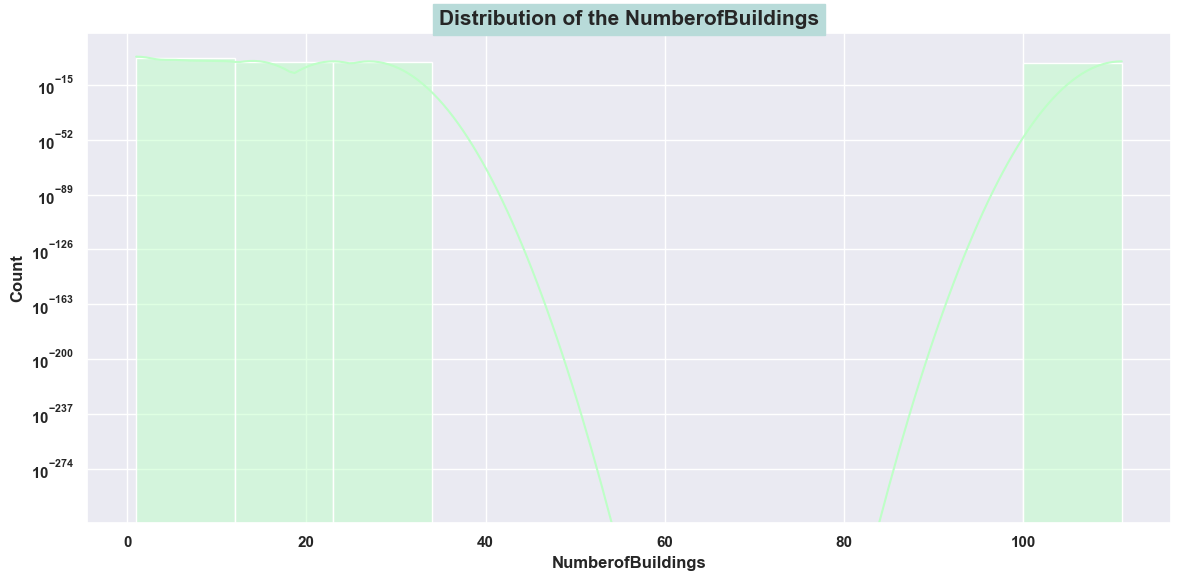

In [99]:
# let's plot the distribution of the plot
fig, ax = plt.subplots(nrows=1, ncols=1)
sns.histplot(data=df_compliant_filtered,
             x='NumberofBuildings',
             element='bars',
             kde=True,
             stat='count',
             bins=10,
             ax=ax,
             color='#BEFFC7')
ax.set_title('Distribution of the NumberofBuildings', fontsize=15, fontweight='bold', backgroundcolor='#B8DBD9')
ax.set_yscale(value='log')
plt.tight_layout()
plt.show()

## Because of the skewness of this column, we'll binarize the values in two categories 0, for those which have 1 building and 1 for all the remaining

In [100]:
df_compliant_filtered['IsComplex'] = (df_compliant_filtered['NumberofBuildings'] > 1).astype(dtype=pd.Int32Dtype())

In [101]:
df_compliant_filtered['IsComplex'].value_counts(normalize=True, ascending=False, sort=True)

IsComplex
0    0.965194
1    0.034806
Name: proportion, dtype: Float64

## NumberofFloors column analysis

In [102]:
df_compliant_filtered['NumberofFloors'].nunique()

45

In [103]:
df_compliant_filtered['NumberofFloors'].mode()

0    1
Name: NumberofFloors, dtype: int64

In [104]:
# let's print the statistics of the column
numeric_describe(df=df_compliant_filtered, col='NumberofFloors')

count    1494.000000
mean        4.293173
std         6.851970
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        99.000000
mode        1.000000
Name: NumberofFloors, dtype: float64

In [105]:
df_compliant_filtered['NumberofFloors'].value_counts(sort=True, ascending=False, normalize=False, dropna=True)

NumberofFloors
1     412
2     337
3     229
4     135
5      99
6      80
7      33
8      21
11     18
10     16
0      15
12      9
14      9
9       8
13      7
15      5
42      5
19      4
17      4
18      3
25      3
33      3
20      3
16      3
23      3
22      3
29      3
21      3
41      2
24      2
34      2
36      2
28      1
47      1
49      1
37      1
63      1
55      1
46      1
30      1
56      1
76      1
27      1
99      1
39      1
Name: count, dtype: int64

In [106]:
df[df['NumberofFloors'] == 0][['PropertyName', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PrimaryPropertyType']]

,PropertyName,NumberofBuildings,NumberofFloors,PropertyGFATotal,PrimaryPropertyType
166,Grand Hyatt Seattle,1.0,0,934292,Hotel
487,Arnold Pavilion,1.0,0,225982,Medical Office
488,2200 Westlake - SEDO,0.0,0,516407,Mixed Use Property
564,Pacific Place,1.0,0,947987,Other
1754,HART First Hill LLC,1.0,0,274568,Medical Office
1993,(ID#24086)Campus1:KC Metro Transit Atlantic Ce...,10.0,0,230971,Other
3130,Sandpoint #5,1.0,0,384772,Warehouse
3131,Sandpoint #25,1.0,0,30287,Medical Office
3132,Sandpoint #29,1.0,0,21931,Small- and Mid-Sized Office
3168,Magnuson,8.0,0,502030,Other


In [107]:
# let's go with another filter on the NumberofBuildings and the NumberofFloors
df[(df['NumberofBuildings'] > 1) & (df['NumberofFloors'] != 0)][['PropertyGFATotal', 'PropertyName', 'PrimaryPropertyType', 'NumberofBuildings', 'NumberofFloors']]

,PropertyGFATotal,PropertyName,PrimaryPropertyType,NumberofBuildings,NumberofFloors
36,714095,Seattle 11-13,Warehouse,3.0,2
80,50017,UNIVERSITY INN,Hotel,2.0,4
98,285333,Swedish Ballard,Hospital,4.0,5
105,441071,SSCC MAIN CAMPUS,University,27.0,2
117,250981,Youth Services Center,Other,3.0,6
...,...,...,...,...,...
3288,83296,Belroy Apartments Modern,Mid-Rise Multifamily,3.0,6
3299,42905,129610 - Identity Seattle Building I,Mid-Rise Multifamily,2.0,7
3323,271922,Junction 47,Mid-Rise Multifamily,2.0,6
3326,318835,Odin,Mid-Rise Multifamily,2.0,7


In [108]:
df.query(expr="NumberofFloors >= 10 and NumberofBuildings == 1", inplace=False)[['PrimaryPropertyType', 'NumberofFloors', 'NumberofBuildings',
                                                                                 'PropertyName', 'YearBuilt', 'PropertyGFATotal']].sort_values(by='NumberofFloors',ascending=False,
                                                                                                              kind='quicksort',
                                                                                                              ignore_index=False)

,PrimaryPropertyType,NumberofFloors,NumberofBuildings,PropertyName,YearBuilt,PropertyGFATotal
1359,Worship Facility,99,1.0,Seattle Chinese Baptist Church,1977,21948
559,Large Office,76,1.0,Columbia Center - 2015,1985,1952220
233,Large Office,63,1.0,Seattle Municipal Tower (2030),1990,1354987
292,Large Office,56,1.0,Two Union Square,1989,1605578
271,Large Office,55,1.0,1201 Third Avenue,1988,1400000
...,...,...,...,...,...,...
2640,High-Rise Multifamily,10,1.0,University West,1971,78600
2814,Senior Care Community,10,1.0,Bayview Manor,1960,241387
2842,High-Rise Multifamily,10,1.0,Denny Terrace,1969,139127
2936,High-Rise Multifamily,10,1.0,Meridian Manor Apartments,1979,75070


In [109]:
# let's see the same data on the df_compliant_filtered
df_compliant_filtered.query(expr="NumberofFloors >= 10 and NumberofBuildings == 1", inplace=False)[['PrimaryPropertyType', 'NumberofFloors', 'NumberofBuildings',
                                                                                 'YearBuilt', 'PropertyGFATotal']].sort_values(by='NumberofFloors',ascending=False,
                                                                                                              kind='quicksort',
                                                                                                              ignore_index=False)

,PrimaryPropertyType,NumberofFloors,NumberofBuildings,YearBuilt,PropertyGFATotal
1359,Worship Facility,99,1.0,1977,21948
559,Large Office,76,1.0,1985,1952220
233,Large Office,63,1.0,1990,1354987
292,Large Office,56,1.0,1989,1605578
271,Large Office,55,1.0,1988,1400000
...,...,...,...,...,...
287,Large Office,10,1.0,1927,130893
274,Large Office,10,1.0,1958,135918
566,Large Office,10,1.0,1908,132998
610,Large Office,10,1.0,1994,381511


### Outlier identified: The 'Seattle Chinese Baptist Church' building is listed as having 99 floors, exceeding the height of the city's tallest skyscraper (76 floors). This is clearly a data entry error (code 99 or a typo), so we are removing this observation to ensure the robustness of the model.

### We'll replace the buildings with 0 floors with 1 floors it's more logic, because A building has at least one first floor. For trees, changing from 0 to 1 won't alter the overall logic, but it will avoid the mathematical absurdity of a "zero height".

In [110]:
# let's filter the data
df_compliant_filtered = df_compliant_filtered.query(expr="NumberofFloors != 99", inplace=False)

In [111]:
df_compliant_filtered['NumberofFloors'] = df_compliant_filtered['NumberofFloors'].replace(to_replace=0, value=1)

In [112]:
# verification
df_compliant_filtered['NumberofFloors'].describe()

count    1493.000000
mean        4.239786
std         6.394543
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        76.000000
Name: NumberofFloors, dtype: float64

In [113]:
# let's check all the houses with 0 NumberofFloors
df_compliant_filtered.loc[df_compliant_filtered['NumberofFloors'] == 0, :]

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex


2026-02-14 23:47:02 | INFO     | energy_sights.plots - Plotting distribution for column: NumberofFloors
2026-02-14 23:47:02.048 | INFO     | energy_sights.plots:plot_distribution:26 - Plotting distribution for column: NumberofFloors


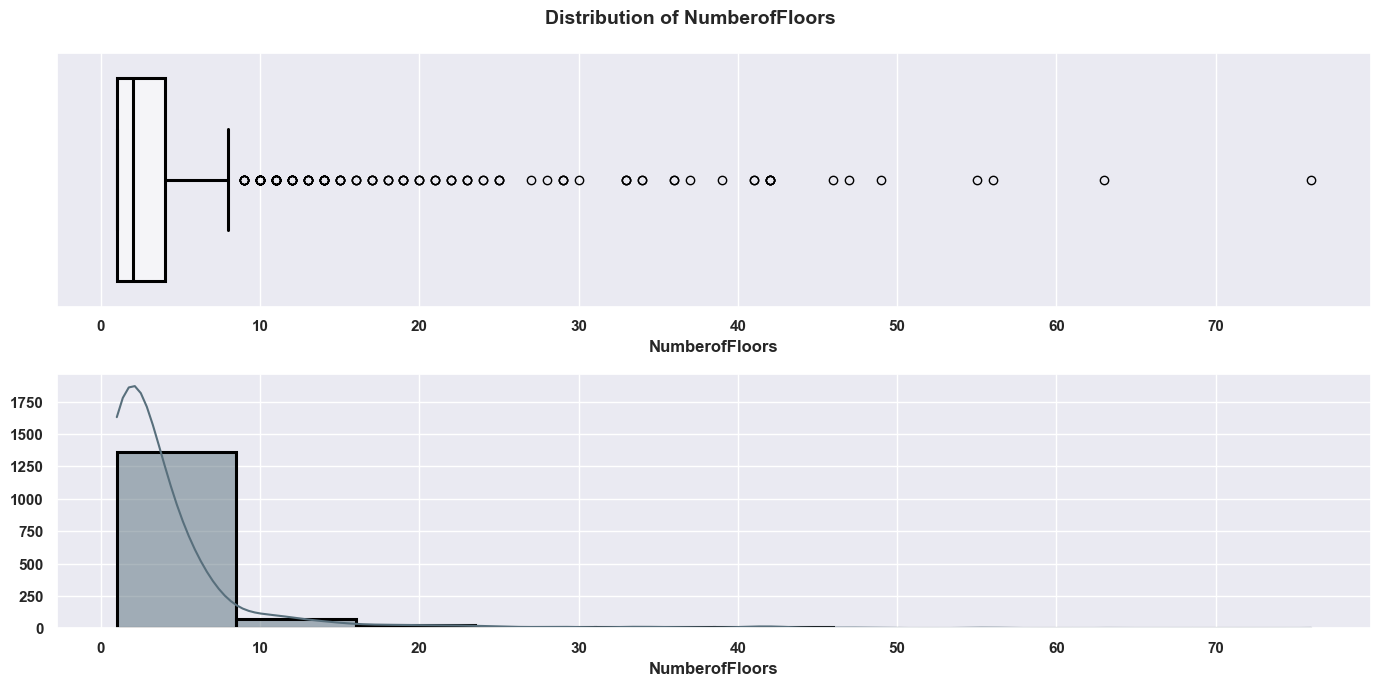

2026-02-14 23:47:02 | SUCCESS  | energy_sights.plots - Plot generation for the column NumberofFloors complete
2026-02-14 23:47:02.781 | SUCCESS  | energy_sights.plots:plot_distribution:51 - Plot generation for the column NumberofFloors complete


In [114]:
# let's take a look at the distribution of this column
plot_distribution(df=df_compliant_filtered, col='NumberofFloors', bins=10)

In [115]:
# let's use plotly to have more interactivity !
fig = px.histogram(data_frame=df_compliant_filtered,
                   x='NumberofFloors',
                   nbins=50,
                    opacity=.7,
                   marginal='box',
                   title='NumberofFloors Distribution')
fig.update_layout(bargap=.1)
fig.show()

## PropertyGFATotal Analysis

In [116]:
# let's start with the statistics
numeric_describe(df=df_compliant_filtered, col='PropertyGFATotal')

count     1.493000e+03
mean      1.215228e+05
std       3.095231e+05
min       1.128500e+04
25%       2.880800e+04
50%       4.800600e+04
75%       1.075720e+05
max       9.320156e+06
mode_1    2.592000e+04
mode_2    2.880000e+04
mode_3    3.600000e+04
Name: PropertyGFATotal, dtype: float64

In [117]:
# let's see the unique values in the PropertyGFATotal
df_compliant_filtered['PropertyGFATotal'].nunique()

1420

In [118]:
df_compliant_filtered.sort_values(by='PropertyGFATotal', ascending=False, kind='quicksort')[['NumberofBuildings', 'NumberofFloors', 'YearBuilt']]

,NumberofBuildings,NumberofFloors,YearBuilt
3274,111.0,1,1900
1494,1.0,2,1939
559,1.0,76,1985
618,7.0,14,1994
292,1.0,56,1989
...,...,...,...
3373,1.0,1,1974
3365,1.0,1,1972
3362,1.0,1,2010
3361,1.0,1,2013


In [119]:
# let's plot the distribution with interactivity
interactive_distribution(df=df_compliant_filtered, col='PropertyGFATotal')

### let's apply the logarithm function on the PropertyGFATotal to see the changes

In [120]:
df_compliant_filtered = logarithm(df=df_compliant_filtered, col='PropertyGFATotal')

2026-02-14 23:47:07 | INFO     | energy_sights.preprocessing - The logarithm function has been used on PropertyGFATotal with success.
2026-02-14 23:47:07.065 | INFO     | energy_sights.preprocessing:logarithm:86 - The logarithm function has been used on PropertyGFATotal with success.


In [121]:
# now let's plot the distribution to see the changes
interactive_distribution(df=df_compliant_filtered, col='PropertyGFATotalLog')

In [122]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog
0,Hotel,1927,88434,0,Downtown,1.0,12,47.61220,-122.33799,7226362.5,249.98,0,11.390012
1,Hotel,1996,103566,15064,Downtown,1.0,11,47.61317,-122.33393,8387933.0,295.86,0,11.547964
2,Hotel,1969,956110,196718,Downtown,1.0,41,47.61393,-122.33810,72587024.0,2089.28,0,13.770628
3,Hotel,1926,61320,0,Downtown,1.0,10,47.61412,-122.33664,6794584.0,286.43,0,11.023861
4,Hotel,1980,175580,62000,Downtown,1.0,18,47.61375,-122.34047,14172606.0,505.01,0,12.075850


In [149]:
# let's drop the column PropertyGFATotalLog, we create this just for the visualization
df_compliant_filtered = df_compliant_filtered.drop(axis=1, labels=['PropertyGFATotalLog'])

### Latitude and Longitude

In [123]:
df_compliant_filtered.filter(items=['Latitude', 'Longitude']).head()

,Latitude,Longitude
0,47.61220,-122.33799
1,47.61317,-122.33393
2,47.61393,-122.33810
3,47.61412,-122.33664
4,47.61375,-122.34047


In [124]:
numeric_describe(df=df_compliant_filtered, col='Longitude')

count    1493.000000
mean     -122.333442
std         0.023345
min      -122.411820
25%      -122.342870
50%      -122.333040
75%      -122.322640
max      -122.261800
mode     -122.298980
Name: Longitude, dtype: float64

In [125]:
numeric_describe(df=df_compliant_filtered, col='Latitude')

count    1493.000000
mean       47.616566
std         0.047058
min        47.509590
25%        47.587810
50%        47.612870
75%        47.649320
max        47.733870
mode       47.662460
Name: Latitude, dtype: float64

### With all the things I see on the internet about the boundaries of the city of Seattle, the data is pretty clean.

In [126]:
# We'll use a scatterplot to push the analysis further
fig = px.scatter(data_frame=df_compliant_filtered,
           x='Longitude',
           y='Latitude',
           opacity=.7,
            title='The City Seattle')
fig.show()

## The first target SiteEnergyUse(kBtu)

In [127]:
# let's first see the statistics about this column, the most important of all the project !
numeric_describe(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)').head(n=10)

count     1.493000e+03
mean      8.860645e+06
std       3.176307e+07
min       5.713320e+04
25%       1.242312e+06
50%       2.701872e+06
75%       7.305474e+06
max       8.739237e+08
mode_1    5.713320e+04
mode_2    7.971180e+04
Name: SiteEnergyUse(kBtu), dtype: float64

In [128]:
# let's see the distribution of the data
interactive_distribution(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)', n_bins=100_000)

In [129]:
max_consumption = df_compliant_filtered['SiteEnergyUse(kBtu)'].max()

In [130]:
max_consumption

np.float64(873923712.0)

In [131]:
# let's check the building with the highest consumption
df_compliant_filtered.loc[df_compliant_filtered['SiteEnergyUse(kBtu)'] == max_consumption]
# So it's the university of Washington

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog
3274,University,1900,9320156,0,Northeast,111.0,1,47.65644,-122.31041,873923712.0,11140.56,1,16.04769


In [132]:
# because of this skewness we must normalize this column for the training of the model
df_compliant_filtered = logarithm(df=df_compliant_filtered, col='SiteEnergyUse(kBtu)')

2026-02-14 23:47:13 | INFO     | energy_sights.preprocessing - The logarithm function has been used on SiteEnergyUse(kBtu) with success.
2026-02-14 23:47:13.393 | INFO     | energy_sights.preprocessing:logarithm:86 - The logarithm function has been used on SiteEnergyUse(kBtu) with success.


In [133]:
df_compliant_filtered.head()

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog,SiteEnergyUse(kBtu)Log
0,Hotel,1927,88434,0,Downtown,1.0,12,47.61220,-122.33799,7226362.5,249.98,0,11.390012,15.793246
1,Hotel,1996,103566,15064,Downtown,1.0,11,47.61317,-122.33393,8387933.0,295.86,0,11.547964,15.942305
2,Hotel,1969,956110,196718,Downtown,1.0,41,47.61393,-122.33810,72587024.0,2089.28,0,13.770628,18.100297
3,Hotel,1926,61320,0,Downtown,1.0,10,47.61412,-122.33664,6794584.0,286.43,0,11.023861,15.731636
4,Hotel,1980,175580,62000,Downtown,1.0,18,47.61375,-122.34047,14172606.0,505.01,0,12.075850,16.466822


## 2nd Target: TotalGHGEmissions

In [134]:
# let's see the core statistics on the columns
numeric_describe(df=df_compliant_filtered, col='TotalGHGEmissions')

count     1493.000000
mean       193.334528
std        790.721214
min         -0.800000
25%         20.300000
50%         49.580000
75%        146.930000
max      16870.980000
mode         6.300000
Name: TotalGHGEmissions, dtype: float64

In [135]:
interactive_distribution(df=df_compliant_filtered, col='TotalGHGEmissions')

In [136]:
# let's see the lines with the TotalGHGEmissions negative
df_compliant_filtered.query(expr="TotalGHGEmissions <= 0", inplace=False)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog,SiteEnergyUse(kBtu)Log
513,Supermarket / Grocery Store,2008,57176,0,Magnolia / Queen Anne,1.0,1,47.63718,-122.37734,1.252517e+07,0.0,0,10.953890,16.343251
3206,Small- and Mid-Sized Office,2013,52000,0,Central,1.0,6,47.61432,-122.31257,3.427261e+05,-0.8,0,10.858999,12.744687


In [137]:
# because it's logically impossible to not have greenhouse gases emissions or negative values, we'll remove those weird values
df_compliant_filtered = df_compliant_filtered.query(expr="TotalGHGEmissions > 0", inplace=False)

In [138]:
# let's check the replacement
df_compliant_filtered[df_compliant_filtered['TotalGHGEmissions'] <= 0]
# perfect the replacement is effective

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofBuildings,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog,SiteEnergyUse(kBtu)Log


## Features Creation

In [139]:
df_compliant_filtered = engineer_features(df=df_compliant_filtered)

2026-02-14 23:47:20 | INFO     | energy_sights.features - Launching the features creation pipeline
2026-02-14 23:47:20.248 | INFO     | energy_sights.features:engineer_features:61 - Launching the features creation pipeline
2026-02-14 23:47:20 | INFO     | energy_sights.features - Binarization of the features
2026-02-14 23:47:20.258 | INFO     | energy_sights.features:create_binarization:13 - Binarization of the features
2026-02-14 23:47:20 | INFO     | energy_sights.features - Creation of the column based on the BuiltYear.
2026-02-14 23:47:20.268 | INFO     | energy_sights.features:create_date:25 - Creation of the column based on the BuiltYear.
2026-02-14 23:47:20 | SUCCESS  | energy_sights.features - New columns: 3
2026-02-14 23:47:20.341 | SUCCESS  | energy_sights.features:engineer_features:67 - New columns: 3


In [140]:
# let's check the data
df_compliant_filtered.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 1491 entries, 0 to 3375
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PrimaryPropertyType     1491 non-null   str    
 1   YearBuilt               1491 non-null   int64  
 2   PropertyGFATotal        1491 non-null   int64  
 3   PropertyGFAParking      1491 non-null   int64  
 4   Neighborhood            1491 non-null   str    
 5   NumberofFloors          1491 non-null   int64  
 6   Latitude                1491 non-null   float64
 7   Longitude               1491 non-null   float64
 8   SiteEnergyUse(kBtu)     1491 non-null   float64
 9   TotalGHGEmissions       1491 non-null   float64
 10  IsComplex               1491 non-null   Int32  
 11  PropertyGFATotalLog     1491 non-null   float64
 12  SiteEnergyUse(kBtu)Log  1491 non-null   float64
 13  BuildingAge             1491 non-null   int64  
 14  AverageFloorArea        1491 non-null   float64
 15  Dis

In [141]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,PropertyGFATotalLog,SiteEnergyUse(kBtu)Log,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,1927,88434,0,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,11.390012,15.793246,89,7369.500000,11742.615082,0.000000
1,Hotel,1996,103566,15064,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,11.547964,15.942305,20,9415.090909,11743.170496,0.145453
2,Hotel,1969,956110,196718,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,13.770628,18.100297,47,23319.756098,11742.794402,0.205748
3,Hotel,1926,61320,0,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,11.023861,15.731636,90,6132.000000,11742.976556,0.000000
4,Hotel,1980,175580,62000,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,12.075850,16.466822,36,9754.444444,11742.512927,0.353115


In [142]:
# let's check the strings and categorical data
df_compliant_filtered.select_dtypes(include='string')

,PrimaryPropertyType,Neighborhood
0,Hotel,Downtown
1,Hotel,Downtown
2,Hotel,Downtown
3,Hotel,Downtown
4,Hotel,Downtown
...,...,...
3370,Other,Delridge Neighborhoods
3372,Other,Downtown
3373,Other,Magnolia / Queen Anne
3374,Mixed Use Property,Greater Duwamish


In [143]:
# let's check the granularity of the data in those columns
df_compliant_filtered.select_dtypes(include='string').nunique()

PrimaryPropertyType    16
Neighborhood           13
dtype: int64

In [150]:
df_compliant_filtered.head(n=5)

,PrimaryPropertyType,YearBuilt,PropertyGFATotal,PropertyGFAParking,Neighborhood,NumberofFloors,Latitude,Longitude,SiteEnergyUse(kBtu),TotalGHGEmissions,IsComplex,SiteEnergyUse(kBtu)Log,BuildingAge,AverageFloorArea,DistToCenter,ParkingRatio
0,Hotel,1927,88434,0,Downtown,12,47.61220,-122.33799,7226362.5,249.98,0,15.793246,89,7369.500000,11742.615082,0.000000
1,Hotel,1996,103566,15064,Downtown,11,47.61317,-122.33393,8387933.0,295.86,0,15.942305,20,9415.090909,11743.170496,0.145453
2,Hotel,1969,956110,196718,Downtown,41,47.61393,-122.33810,72587024.0,2089.28,0,18.100297,47,23319.756098,11742.794402,0.205748
3,Hotel,1926,61320,0,Downtown,10,47.61412,-122.33664,6794584.0,286.43,0,15.731636,90,6132.000000,11742.976556,0.000000
4,Hotel,1980,175580,62000,Downtown,18,47.61375,-122.34047,14172606.0,505.01,0,16.466822,36,9754.444444,11742.512927,0.353115


### Correlation


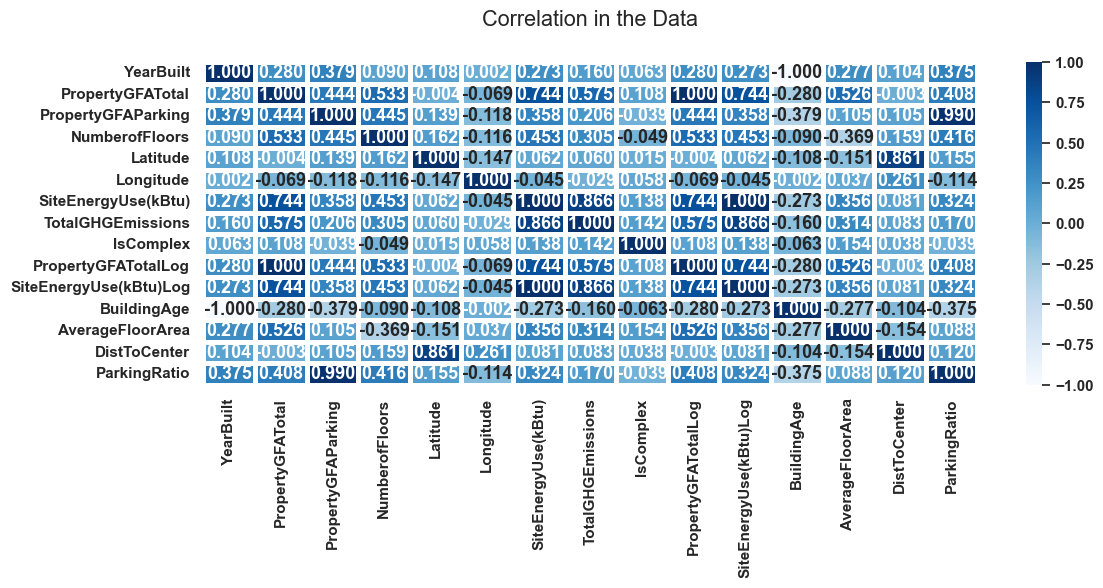

2026-02-14 23:47:27 | INFO     | energy_sights.plots - The heat_correlation is done: corr_shape (15, 15)
2026-02-14 23:47:27.468 | INFO     | energy_sights.plots:heat_correlation:92 - The heat_correlation is done: corr_shape (15, 15)


In [146]:
# let's now study the correlation between all the variables and the target !
heat_correlation(df=df_compliant_filtered, num_only=True, method='spearman')

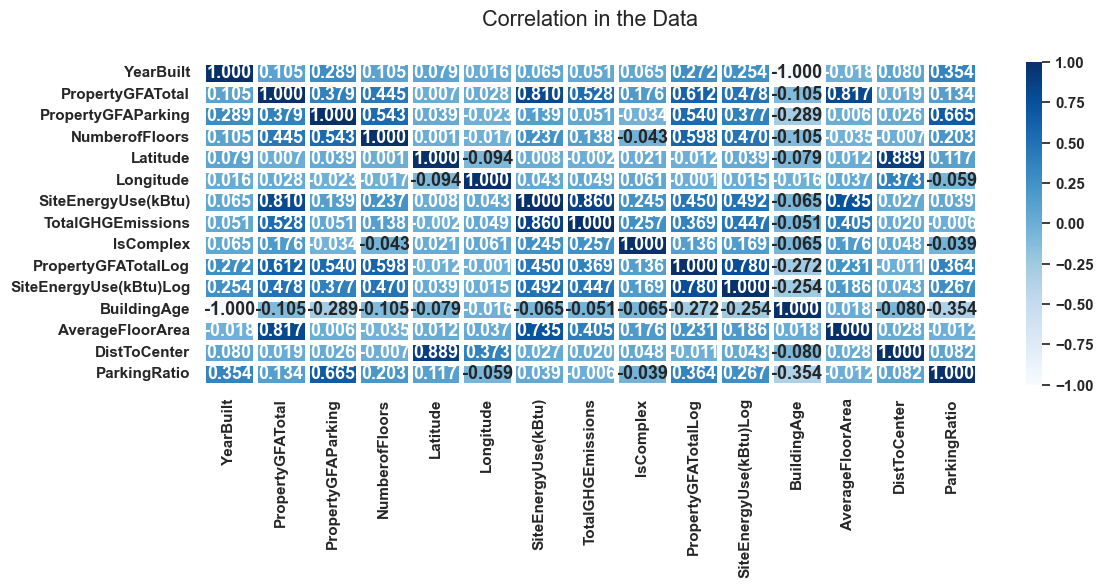

2026-02-14 23:47:29 | INFO     | energy_sights.plots - The heat_correlation is done: corr_shape (15, 15)
2026-02-14 23:47:29.478 | INFO     | energy_sights.plots:heat_correlation:92 - The heat_correlation is done: corr_shape (15, 15)


In [147]:
# let's also test the pearson method
heat_correlation(df=df_compliant_filtered, num_only=True, method='pearson')

In [ ]:
# let's clean the data to avoid collinearity between the features of the models
df_compliant_filtered = df_compliant_filtered.drop(columns=[
    'PropertyGFAParking'
])

## Data Export

In [144]:
processed_dir: Path = PROCESSED_DATA_DIR / 'processed_data.csv'

In [145]:
df_compliant_filtered.to_csv(path_or_buf=processed_dir, sep=',', index=False, decimal='.')